In [ ]:
pip install pycaret

In [1]:
from pycaret.datasets import get_data

In [2]:
dataset = get_data('forest')

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [3]:
dataset.shape

(517, 13)

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [5]:
from pycaret import regression
s = regression.setup(dataset,
                     categorical_features=['month', 'day'],
                     normalize = True,
                     target='area',
                     session_id = 123)

,Description,Value
0,Session id,123
1,Target,area
2,Target type,Regression
3,Original data shape,"(517, 13)"
4,Transformed data shape,"(517, 30)"
5,Transformed train set shape,"(361, 30)"
6,Transformed test set shape,"(156, 30)"
7,Numeric features,10
8,Categorical features,2
9,Preprocess,True


In [9]:
best_model = regression.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,15.1291,5709.6109,54.0750,-0.0897,1.4504,1.0576,0.0810
br,Bayesian Ridge,22.1882,5562.7788,53.7626,-0.2506,2.1849,5.8200,0.0610
dummy,Dummy Regressor,22.1849,5566.8769,53.7747,-0.2509,2.1856,5.7776,0.0610
par,Passive Aggressive Regressor,20.6801,5795.4458,55.8287,-0.2917,1.9214,3.3226,0.0730
en,Elastic Net,23.0054,5584.4868,54.8793,-0.4438,2.1198,6.4504,0.0590
omp,Orthogonal Matching Pursuit,23.6360,5570.6718,54.9156,-0.5275,2.1419,7.4327,0.0580
lasso,Lasso Regression,24.2361,5644.5317,55.9775,-0.6267,2.1735,7.0604,0.0630
llar,Lasso Least Angle Regression,24.2363,5644.5404,55.9777,-0.6267,2.1735,7.0604,0.0550
ridge,Ridge Regression,26.1582,5698.6546,57.3213,-0.9379,2.2531,7.3629,0.0620
ada,AdaBoost Regressor,27.5172,6302.8813,62.6896,-1.3675,2.2949,8.7711,0.0590


Processing:   0%|          | 0/77 [00:00<?, ?it/s]

In [34]:
print(best_model)

HuberRegressor()


In [12]:
trained_model = regression.finalize_model(best_model)

In [13]:
predictions = regression.predict_model(trained_model, data=dataset)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Huber Regressor,12.7280,4154.7943,64.4577,-0.0273,1.3591,0.9190


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

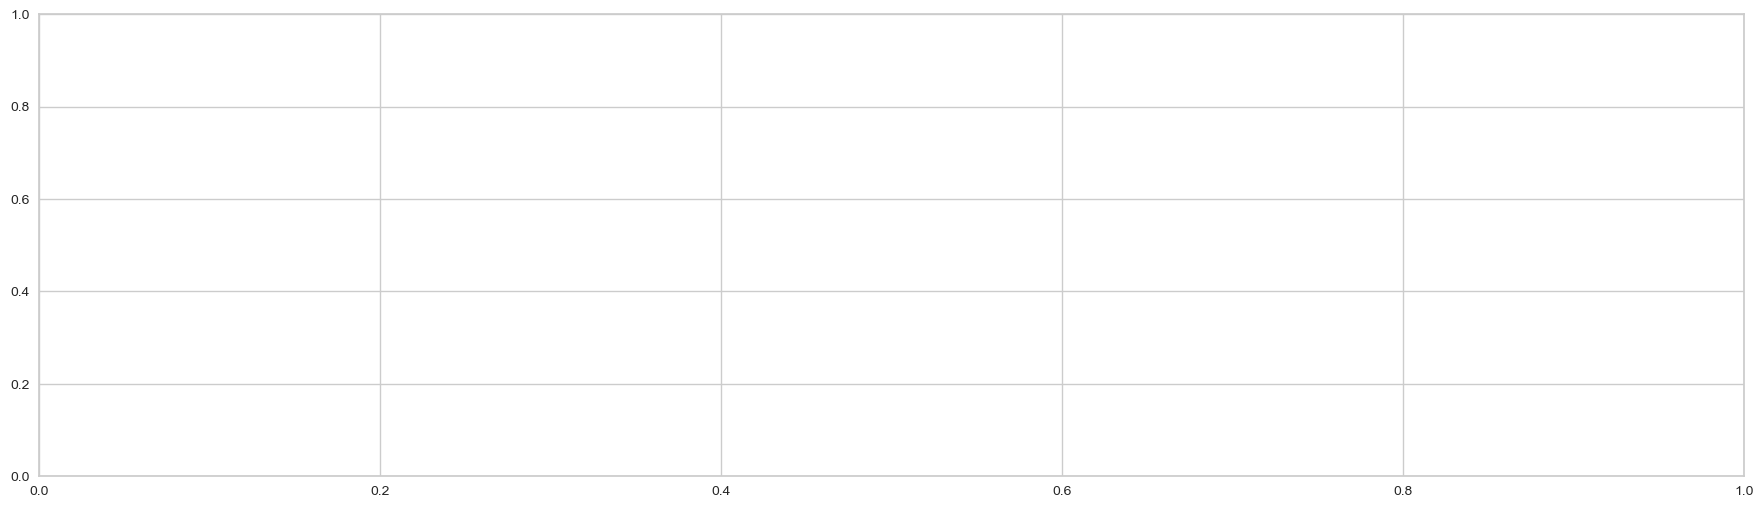

In [17]:
regression.evaluate_model(trained_model)

In [22]:
# predict on new data
new_data = dataset.drop('area', axis = 1).sample(5, random_state = 42)
predictions = regression.predict_model(best_model, data = new_data)
predictions.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,prediction_label
304,6,5,may,sat,85.099998,28.000000,113.800003,3.5,11.300000,94,4.9,0.0,-0.000071
501,7,5,aug,tue,96.099998,181.100006,671.200012,14.3,21.600000,65,4.9,0.8,3.618078
441,8,6,aug,mon,92.099998,207.000000,672.599976,8.2,25.500000,29,1.8,0.0,2.211463
153,5,4,sep,fri,94.300003,85.099998,692.299988,15.9,20.100000,47,4.9,0.0,1.740898
503,2,4,aug,wed,94.500000,139.399994,689.099976,20.0,29.200001,30,4.9,0.0,1.834190


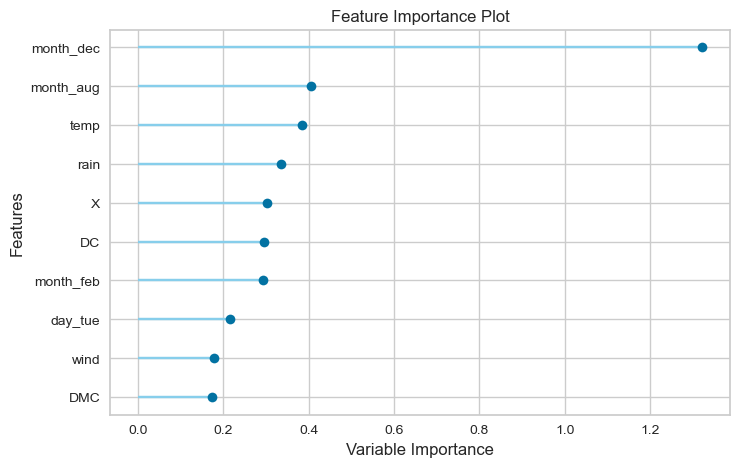

In [23]:
regression.plot_model(best_model, plot = 'feature')

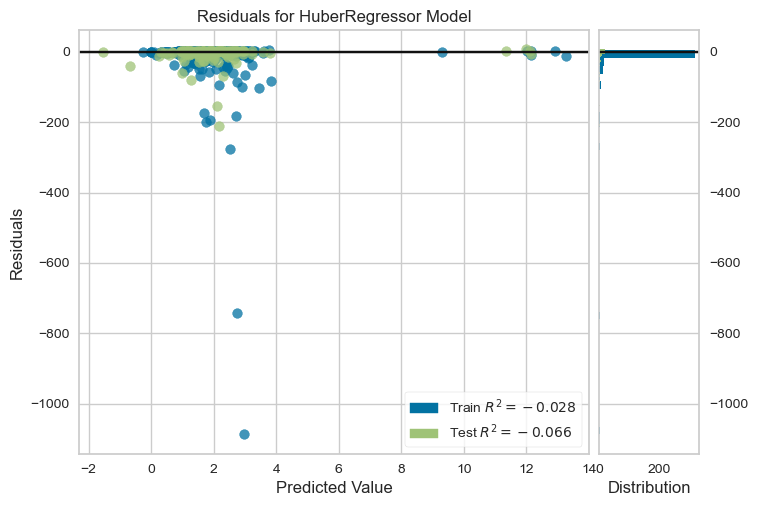

In [24]:
regression.plot_model(best_model, plot = 'residuals')

In [33]:
regression.save_model(trained_model, 'forest_regression_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=FastMemory(location=/var/folders/fg/qyp6wb_d3pl2l92zmw74ch300000gn/T/joblib),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['X', 'Y', 'FFMC', 'DMC', 'DC',
                                              'ISI', 'temp', 'RH', 'wind',
                                              'rain'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=['month', 'day'],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('onehot_encoding',
                  TransformerWrapper(include=['month', 'day'],
                                     transformer=OneHotEncoder(cols=['month',
                                                                     'day'],
                                                               handle_missing='return_nan',
                                                